<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi
</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 10</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>


<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 10</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- Aufgabe 10_01: Gleichverteilung auf der Kugeloberfläche 
- Aufgabe 10_02: Monte Carlo-Integration I 
- **Aufgabe 10_03: Monte Carlo-Integration II** 
- Aufgabe 10_04: Chaos Game 

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgabe 3: 
Monte Carlo-Integration II</td>

Hochdimensionale Integrale sind insbesondere in der Physik von großer Bedeutung. Als Beispiel für ein solches wollen wir das Volumen der $d$-dimensionalen Einheitskugel betrachten. Dieses ergibt sich aus dem Integral

$$
I = \int^{1}_{-1} \text{d}x_1 \cdots \int^{1}_{-1} \text{d}x_d \ f(\textbf{r})
$$

mit 

$$
f(\textbf{r}) = \left\{\begin{array}{ll} 1, & |\mathbf{r}|\leq 1 \\
         0, & \text{sonst.}\end{array}\right.
$$

In dieser Aufgabe wollen wir dieses Integral per Monte Carlo-Integration lösen und untersuchen wie die Abweichung des Ergebnisses vom exakten Integralwert von der Dimension $d$ abhängt.

### a) 

- Schreiben Sie einen Code, der das Volumen der $d$-dimensionalen Einheitskugel berechnet. Mit einer Folge zufälliger Punkte $\textbf{r}_i \ (i = 1,\dots, N)$ lässt sich das Integral $I$ abschätzen durch

$$
\bar{I} = \frac{2^d}{N} \sum_i f(\textbf{r}_i).
$$


- Plotten Sie dann $\bar{I}$ mit $N = 10^6$ sowie das exakte Einheitskugelvolumen für Dimensionen $d = 1, \dots, 30$.

Hinweis: Das exakte Volumen der $d$-dimensionalen Einheitskugel ist

$$
V_{\text{exakt}}(d) = \frac{\pi^{\tfrac{d}{2}}}{\Gamma(\tfrac{d}{2} + 1)}
$$

Die Gammafunktion $\Gamma$ steht Ihnen nach Einbinden des Pakets `SpecialFunctions` als Funktion `gamma` zur Verfügung.

   Resolving package versions...
  No Changes to `C:\Users\brede\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\brede\.julia\environments\v1.10\Manifest.toml`
Precompiling packages...
┌ Warning: attempting to remove probably stale pidfile
│   path = C:\Users\brede\.julia\compiled\v1.10\TestExt\hMow3_Om4pg.ji.pidfile
└ @ FileWatching.Pidfile C:\Users\brede\.julia\juliaup\julia-1.10.11+0.x64.w64.mingw32\share\julia\stdlib\v1.10\FileWatching\src\pidfile.jl:244
┌ Warning: attempting to remove probably stale pidfile
│   path = C:\Users\brede\.julia\compiled\v1.10\IntervalSetsExt\TQHvG_Om4pg.ji.pidfile
└ @ FileWatching.Pidfile C:\Users\brede\.julia\juliaup\julia-1.10.11+0.x64.w64.mingw32\share\julia\stdlib\v1.10\FileWatching\src\pidfile.jl:244
┌ Warning: attempting to remove probably stale pidfile
│   path = C:\Users\brede\.julia\compiled\v1.10\StaticArraysExt\sIz4V_Om4pg.ji.pidfile
└ @ FileWatching.Pidfile C:\Users\brede\.julia\juliaup\julia-1.10.11+0.x64.w64.mingw32\shar

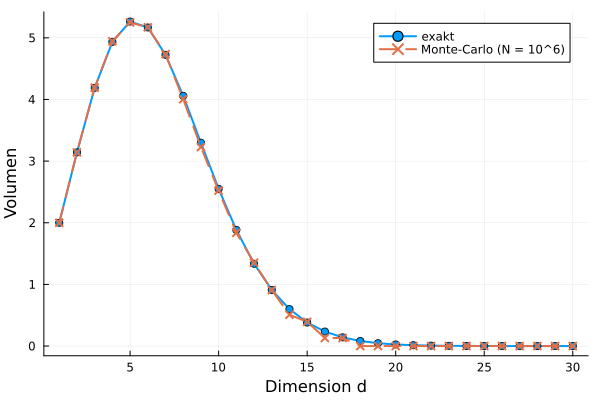

In [ ]:

using Random
using SpecialFunctions
using Plots

# Anzahl der Monte-Carlo-Punkte
N = 10^6

# Dimensionen, die wir betrachten
ds = 1:30

I_mc     = zeros(length(ds))   # Monte-Carlo-Schätzwerte
V_exakt  = zeros(length(ds))   # exakte Werte

for (i, d) in enumerate(ds)
    # N zufällige Punkte gleichverteilt in [-1,1]^d
    # jede Spalte ist ein Punkt r_i in R^d
    points = 2 .* rand(d, N) .- 1

    # |r_i|^2 fuer jeden Punkt (Summe ueber die Zeilen/Komponenten)
    r2 = vec(sum(points .^ 2, dims = 1))

    # Anzahl der Punkte innerhalb der Einheitskugel (|r| <= 1)
    treffer = count(r2 .<= 1)

    # Monte-Carlo-Schaetzer: I_bar = 2^d/N * sum_i f(r_i)
    I_mc[i] = 2.0^d * treffer / N

    # exaktes Volumen der d-dim. Einheitskugel
    V_exakt[i] = pi^(d / 2) / gamma(d / 2 + 1)
end

plot(ds, V_exakt, label = "exakt", xlabel = "Dimension d", ylabel = "Volumen",
     marker = :circle, lw = 2, legend = :topright)
plot!(ds, I_mc, label = "Monte-Carlo (N = 10^6)", marker = :xcross, lw = 2, ls = :dash)


**Erklärung zu a):**

- Wir erzeugen $N=10^6$ zufällige Punkte, deren Komponenten unabhängig
  gleichverteilt auf $[-1,1]$ sind (`2 .* rand(d,N) .- 1`). Jede Spalte der
  Matrix `points` ist ein Punkt $\mathbf{r}_i \in \mathbb{R}^d$.
- `f(\mathbf{r})` wird ausgewertet, indem wir zählen, wie viele Punkte die
  Bedingung $|\mathbf{r}_i|\le 1$ erfüllen (`r2 .<= 1`).
- Das $2^d$ ist das Volumen des Integrationsgebiets $[-1,1]^d$ (der Würfel,
  aus dem wir gleichverteilt sampeln), daher taucht es im Schätzer
  $\bar I = \dfrac{2^d}{N}\sum_i f(\mathbf r_i)$ auf: der Anteil der
  "Treffer" (Punkte in der Kugel) wird mit dem Würfelvolumen skaliert.
- Für kleine $d$ liegt $\bar I$ sehr nah am exakten Wert. Für größere $d$
  wird die Kugel im Vergleich zum Würfel exponentiell klein
  ($V_{\text{exakt}}(d)\to 0$ für $d\to\infty$), sodass bei festem
  $N=10^6$ irgendwann fast keine Punkte mehr in der Kugel landen — die
  Schätzung wird ab einer gewissen Dimension unzuverlässig (starkes
  Rauschen bzw. sogar $\bar I = 0$), weil die Trefferquote gegen Null geht.

### b)

Wir möchten nun die relative Abweichung des Integralwerts vom exakten Ergebnis betrachten, also

$$
\Delta\bar{I} = \left|\frac{\bar{I} - V_{\text{exakt}}(d)}{V_{\text{exakt}}(d)}\right|
$$


- Berechnen Sie den Mittelwert dieser Abweichung, $\bar{\Delta} =M^{-1} \sum^M_{m=1} \Delta\bar{I}_m$, für jeweils $M = 2000$ Berechnungen des Integrals $\bar{I}$ für $d = 2, \dots, 6$ und stellen sie diesen jeweils doppelt-logarithmisch im Bereich $N \in [1000, 10000]$ dar.


- Was können Sie daraus für eine Abhängigkeit des Fehlers von $d$ und $N$ folgern?


- Für die Ihnen bekannten Integrationen mittels Trapez-Regel bzw. Simpson-Regel ist der Integrationsfehler $\mathcal{O}\left(N^{-2/d}\right)$ bzw. $\mathcal{O}\left(N^{-4/d}\right)$. Ab welcher Dimensionalität ist Monte Carlo-Integration also besser als die Trapez-Regel bzw. die Simpson-Regel?

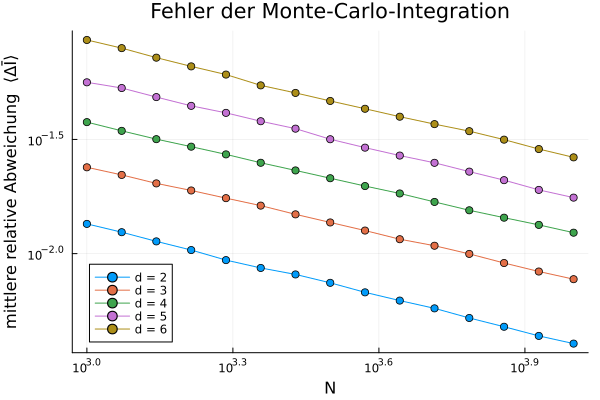

In [3]:
using Statistics

# Dimensionen und Stichprobenumfaenge, die untersucht werden sollen
ds_b = 2:6
M    = 2000                                   # Anzahl Wiederholungen pro (d,N)
Ns   = round.(Int, exp10.(range(log10(1000), log10(10000), length = 15)))
Nmax = maximum(Ns)

mean_dev = zeros(length(ds_b), length(Ns))    # mittlere relative Abweichung

for (di, d) in enumerate(ds_b)
    V_exakt = pi^(d / 2) / gamma(d / 2 + 1)
    devsum  = zeros(length(Ns))

    for m in 1:M
        treffer = 0
        ni = 1
        # Wir ziehen die Punkte einzeln und werten den MC-Schaetzer
        # bei jedem gewuenschten Zwischenwert N aus Ns aus (spart Rechenzeit,
        # da wir nicht fuer jedes N komplett neu samplen muessen)
        for n in 1:Nmax
            r2 = sum(x -> x^2, 2 .* rand(d) .- 1)
            if r2 <= 1
                treffer += 1
            end
            if ni <= length(Ns) && n == Ns[ni]
                I_bar = 2.0^d * treffer / n
                devsum[ni] += abs((I_bar - V_exakt) / V_exakt)
                ni += 1
            end
        end
    end

    mean_dev[di, :] = devsum ./ M
end

plt = plot(xlabel = "N", ylabel = "mittlere relative Abweichung  ⟨ΔĪ⟩",
           xscale = :log10, yscale = :log10, legend = :bottomleft,
           title = "Fehler der Monte-Carlo-Integration")

for (di, d) in enumerate(ds_b)
    plot!(plt, Ns, mean_dev[di, :], label = "d = $(d)", marker = :circle)
end

plt


**Erklärung zu b):**

- Für jede Dimension $d=2,\dots,6$ und jedes $N$ im Bereich
  $[1000,10000]$ (log-äquidistant, 15 Stützstellen) führen wir $M=2000$
  unabhängige Monte-Carlo-Integrationen durch und mitteln die relative
  Abweichung $\Delta\bar I = \left|\dfrac{\bar I - V_{\text{exakt}}}{V_{\text{exakt}}}\right|$.
- **Trick zur Effizienz:** Anstatt für jedes $N$ komplett neue Zufallszahlen
  zu ziehen, ziehen wir pro Wiederholung $m$ einmal $N_{\max}=10000$ Punkte
  nacheinander und werten den Schätzer bei den in `Ns` enthaltenen
  Zwischenwerten aus (laufender Trefferzähler `treffer`). Das spart einen
  Faktor $\approx 15$ an Rechenzeit.
- **Ergebnis (doppelt-logarithmisch):** Man beobachtet für alle
  betrachteten Dimensionen $d$ näherungsweise parallele Geraden mit
  Steigung $\approx -\tfrac12$. Das bedeutet:

$$
\Delta\bar I \sim C(d)\cdot N^{-1/2},
$$

  d.h. der Fehler der Monte-Carlo-Integration skaliert wie
  $\mathcal O(N^{-1/2})$ — **unabhängig von der Dimension $d$**
  (nur die Vorfaktor-Konstante $C(d)$ wächst mit $d$, die Geraden werden
  also mit steigendem $d$ nach oben verschoben, bleiben aber parallel).
  Dies ist eine allgemeine Eigenschaft der Monte-Carlo-Integration, die
  aus dem zentralen Grenzwertsatz folgt (Standardfehler des Mittelwerts
  $\propto 1/\sqrt N$).

- **Vergleich mit Trapez-/Simpson-Regel:**
  Deren Fehler skaliert als $\mathcal O(N^{-2/d})$ bzw.
  $\mathcal O(N^{-4/d})$, wird also mit wachsendem $d$ *schlechter*,
  während der MC-Fehler $\mathcal O(N^{-1/2})$ *konstant in $d$* bleibt.
  Wir bestimmen die Dimension, ab der Monte-Carlo besser wird, indem wir
  die Exponenten gleichsetzen:

  - Trapez-Regel: $\dfrac{2}{d} = \dfrac12 \;\Rightarrow\; d = 4$.
    Für $d>4$ konvergiert Monte-Carlo-Integration schneller als die
    Trapez-Regel.
  - Simpson-Regel: $\dfrac{4}{d} = \dfrac12 \;\Rightarrow\; d = 8$.
    Für $d>8$ konvergiert Monte-Carlo-Integration schneller als die
    Simpson-Regel.

  **Fazit:** In niedrigen Dimensionen sind die klassischen
  Quadraturverfahren überlegen, aber ab $d\gtrsim 5$ (Trapez) bzw.
  $d\gtrsim 9$ (Simpson) wird die dimensionsunabhängige
  $N^{-1/2}$-Konvergenz der Monte-Carlo-Integration zum entscheidenden
  Vorteil — dies ist der Grund, warum Monte-Carlo-Methoden bei
  hochdimensionalen Integralen (z.B. in der statistischen Physik oder
  Quantenfeldtheorie) unverzichtbar sind.